# Part IV – Industry-Level Double Materiality Analysis

## 1. Imports and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_columns", 30)

## 2. Load data

In [3]:
df = pd.read_csv("final_panel.csv", low_memory=False)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFyear range:", df["fyear"].min(), "to", df["fyear"].max())
print("\nESG score range:", round(df["esg_score"].min(), 4), "to", round(df["esg_score"].max(), 4))
df.head()

Shape: (20695, 21)

Columns: ['gvkey', 'permno', 'datadate', 'fyear', 'cusip8', 'sic', 'sic2', 'industry_group', 'esg_score', 'at', 'ni', 'sale', 'ceq', 'dltt', 'dlc', 'size', 'lev', 'roa', 'future_roa', 'future_return', 'n_months']

Fyear range: 2013 to 2023

ESG score range: 0.0381 to 0.8621


,gvkey,permno,datadate,fyear,cusip8,sic,sic2,industry_group,esg_score,at,ni,sale,ceq,dltt,dlc,size,lev,roa,future_roa,future_return,n_months
0,1004,54594.0000,2017-05-31,2016,00036110,5080,50,50,0.2465,1504.1000,56.5000,1767.6000,914.2000,155.3000,2.0000,7.3159,0.1046,0.0376,0.0102,0.2887,12
1,1004,54594.0000,2018-05-31,2017,00036110,5080,50,50,0.2352,1524.7000,15.6000,1748.3000,936.3000,177.2000,0.0000,7.3296,0.1162,0.0102,0.0049,-0.3217,12
2,1004,54594.0000,2019-05-31,2018,00036110,5080,50,50,0.2291,1517.2000,7.5000,2051.8000,905.9000,141.7000,0.0000,7.3246,0.0934,0.0049,0.0021,-0.3232,12
3,1004,54594.0000,2020-05-31,2019,00036110,5080,50,50,0.2591,2079.0000,4.4000,2089.3000,902.6000,670.9000,13.7000,7.6396,0.3293,0.0021,0.0233,1.0699,12
4,1004,54594.0000,2021-05-31,2020,00036110,5080,50,50,0.2694,1539.7000,35.8000,1651.4000,974.4000,193.6000,11.5000,7.3393,0.1332,0.0233,0.0500,0.1550,12


## 3. Apply Fama-French 12 industry classification

In [4]:
def sic_to_ff12(sic):
    try:
        s = int(float(sic))
    except (ValueError, TypeError):
        return "Other"

    if (100 <= s <= 999) or (2000 <= s <= 2399) or (2700 <= s <= 2749) or \
       (2770 <= s <= 2799) or (3100 <= s <= 3199) or (3940 <= s <= 3989):
        return "Consumer Non-Durables"
    elif (2500 <= s <= 2519) or (2590 <= s <= 2599) or (3630 <= s <= 3659) or \
         s in (3710, 3711, 3714, 3716) or (3750 <= s <= 3751) or s == 3792 or \
         (3900 <= s <= 3939) or (3990 <= s <= 3999):
        return "Consumer Durables"
    elif (2520 <= s <= 2589) or (2600 <= s <= 2699) or (2750 <= s <= 2769) or \
         (2800 <= s <= 2829) or (2840 <= s <= 2899) or (3000 <= s <= 3099) or \
         (3200 <= s <= 3569) or (3580 <= s <= 3621) or (3700 <= s <= 3709) or \
         (3717 <= s <= 3749) or (3752 <= s <= 3791) or (3793 <= s <= 3799) or \
         (3830 <= s <= 3839) or (3860 <= s <= 3899):
        return "Manufacturing"
    elif (1200 <= s <= 1399) or (2900 <= s <= 2999):
        return "Energy"
    elif 2830 <= s <= 2836:
        return "Healthcare"
    elif (7372 <= s <= 7374) or (3570 <= s <= 3579) or (3660 <= s <= 3695) or \
         (3810 <= s <= 3829) or (3840 <= s <= 3859):
        return "Technology"
    elif 4800 <= s <= 4899:
        return "Telecom"
    elif 4900 <= s <= 4999:
        return "Utilities"
    elif (5000 <= s <= 5999) or (7000 <= s <= 7299) or (7400 <= s <= 7499):
        return "Retail & Services"
    elif 6000 <= s <= 6999:
        return "Finance"
    else:
        return "Other"


df["ff12"] = df["sic"].apply(sic_to_ff12)

# Exclude unclassifiable firms (agriculture, construction, misc.)
df_iv = df[df["ff12"] != "Other"].copy()

print("FF12 distribution (firm-year obs):")
print(df_iv["ff12"].value_counts())
print(f"\nTotal obs after excluding 'Other': {len(df_iv):,}")

FF12 distribution (firm-year obs):
ff12
Finance                  4172
Technology               2834
Manufacturing            2563
Healthcare               2049
Retail & Services        1939
Consumer Non-Durables     960
Utilities                 797
Energy                    735
Consumer Durables         536
Telecom                   368
Name: count, dtype: int64

Total obs after excluding 'Other': 16,953


## 4. Winsorize continuous variables

In [5]:
def winsorize_series(s, lower=0.01, upper=0.99):
    if s.notna().sum() == 0:
        return s
    return s.clip(s.quantile(lower), s.quantile(upper))


for col in ["esg_score", "future_return", "roa", "future_roa", "size", "lev"]:
    df_iv[col + "_w"] = winsorize_series(df_iv[col])

# Convert to percentage units for readability in tables and plots
df_iv["esg_pct"]    = df_iv["esg_score_w"]    * 100   # 0-100
df_iv["ret_pct"]    = df_iv["future_return_w"] * 100   # %
df_iv["roa_pct"]    = df_iv["roa_w"]           * 100   # %

print("Winsorized variable ranges:")
for col in ["esg_pct", "ret_pct", "roa_pct"]:
    print(f"  {col}: [{df_iv[col].min():.2f}, {df_iv[col].max():.2f}]")

Winsorized variable ranges:
  esg_pct: [8.07, 84.99]
  ret_pct: [-75.95, 217.57]
  roa_pct: [-82.23, 26.99]


## 5. Industry-level aggregation

In [6]:
grp = (
    df_iv.groupby("ff12")
    .agg(
        n_obs      = ("gvkey",    "count"),
        n_firms    = ("gvkey",    "nunique"),
        esg_mean   = ("esg_pct",  "mean"),
        esg_median = ("esg_pct",  "median"),
        esg_std    = ("esg_pct",  "std"),
        roa_mean   = ("roa_pct",  "mean"),
        roa_median = ("roa_pct",  "median"),
        ret_mean   = ("ret_pct",  "mean"),
        ret_median = ("ret_pct",  "median"),
        size_mean  = ("size_w",   "mean"),
        lev_mean   = ("lev_w",    "mean"),
    )
    .reset_index()
    .rename(columns={"ff12": "Industry"})
    .sort_values("esg_mean", ascending=False)
    .reset_index(drop=True)
)

print("Industry-level summary (sorted by ESG):")
print(grp[["Industry","n_firms","esg_mean","roa_mean","ret_mean"]]
      .rename(columns={"esg_mean":"ESG (%)","roa_mean":"ROA (%)","ret_mean":"Return (%)"})
      .to_string(index=False))

Industry-level summary (sorted by ESG):
             Industry  n_firms  ESG (%)  ROA (%)  Return (%)
            Utilities      102  50.5849   1.8576     11.3631
Consumer Non-Durables      138  46.4322   5.5792      9.1074
        Manufacturing      353  45.4856   4.4734     12.8755
    Retail & Services      290  42.8158   5.3353     13.1264
    Consumer Durables       78  42.7286   3.8925      8.5949
           Technology      462  42.5207  -0.0837     16.3073
               Energy      127  38.7175  -0.6194     10.3174
              Finance      630  37.7513   2.2308     11.1479
              Telecom       64  34.3026   1.6748      6.2122
           Healthcare      449  31.9005 -27.0189      9.5995


## 6. Double materiality quadrant classification

In [ ]:
ESG_CUT = grp["esg_mean"].median()
RET_CUT = grp["ret_mean"].median()

print(f"ESG threshold  (median of industry means): {ESG_CUT:.2f}%")
print(f"Return threshold (median of industry means): {RET_CUT:.2f}%")

def classify(row):
    hi_esg = row["esg_mean"] >= ESG_CUT
    hi_ret = row["ret_mean"] >= RET_CUT
    if hi_esg and hi_ret:
        return "Double Materiality Winner"
    elif hi_esg and not hi_ret:
        return "ESG Leader, Low Returns"
    elif not hi_esg and hi_ret:
        return "ESG Laggard, High Returns"
    else:
        return "Double Laggard"


grp["Quadrant"] = grp.apply(classify, axis=1)

COLORS = {
    "Double Materiality Winner" : "#27ae60",
    "ESG Leader, Low Returns"   : "#2980b9",
    "ESG Laggard, High Returns" : "#e67e22",
    "Double Laggard"            : "#c0392b",
}
grp["color"] = grp["Quadrant"].map(COLORS)

print("\n── Quadrant assignments ──")
print(grp[["Industry","esg_mean","ret_mean","roa_mean","Quadrant"]]
      .rename(columns={"esg_mean":"ESG (%)","ret_mean":"Return (%)","roa_mean":"ROA (%)"})
      .sort_values("Quadrant")
      .to_string(index=False))

ESG threshold  (median of industry means): 42.62%
Return threshold (median of industry means): 10.73%

── Quadrant assignments ──
             Industry  ESG (%)  Return (%)  ROA (%)                  Quadrant
               Energy  38.7175     10.3174  -0.6194            Double Laggard
              Telecom  34.3026      6.2122   1.6748            Double Laggard
           Healthcare  31.9005      9.5995 -27.0189            Double Laggard
            Utilities  50.5849     11.3631   1.8576 Double Materiality Winner
        Manufacturing  45.4856     12.8755   4.4734 Double Materiality Winner
    Retail & Services  42.8158     13.1264   5.3353 Double Materiality Winner
           Technology  42.5207     16.3073  -0.0837 ESG Laggard, High Returns
              Finance  37.7513     11.1479   2.2308 ESG Laggard, High Returns
Consumer Non-Durables  46.4322      9.1074   5.5792   ESG Leader, Low Returns
    Consumer Durables  42.7286      8.5949   3.8925   ESG Leader, Low Returns


## 7. Table 1 – Industry summary statistics

In [ ]:
table1 = grp[[
    "Industry", "Quadrant", "n_firms",
    "esg_mean", "esg_median",
    "roa_mean", "roa_median",
    "ret_mean", "ret_median",
]].copy()

table1.columns = [
    "Industry", "Quadrant", "N Firms",
    "ESG Mean (%)", "ESG Median (%)",
    "ROA Mean (%)", "ROA Median (%)",
    "Return Mean (%)", "Return Median (%)",
]

for c in table1.columns[3:]:
    table1[c] = table1[c].round(2)

table1 = table1.sort_values(["Quadrant", "ESG Mean (%)"], ascending=[True, False])

print("Table 1: Industry-Level Summary Statistics (2013–2023)")
print(table1.to_string(index=False))

Table 1: Industry-Level Summary Statistics (2013–2023)
             Industry                  Quadrant  N Firms  ESG Mean (%)  ESG Median (%)  ROA Mean (%)  ROA Median (%)  Return Mean (%)  Return Median (%)
               Energy            Double Laggard      127       38.7200         34.5000       -0.6200          2.5800          10.3200            -0.3600
              Telecom            Double Laggard       64       34.3000         30.4700        1.6700          1.9200           6.2100             2.5900
           Healthcare            Double Laggard      449       31.9000         28.3300      -27.0200        -26.6800           9.6000            -6.2200
            Utilities Double Materiality Winner      102       50.5800         52.8400        1.8600          2.6300          11.3600             9.8300
        Manufacturing Double Materiality Winner      353       45.4900         44.8200        4.4700          5.3100          12.8800             8.3500
    Retail & Services Doubl

## 8. Figure 1 – Double materiality quadrant map

Each bubble is one FF12 industry. Bubble size reflects the number of firms.
Dashed lines mark the sample medians (thresholds).

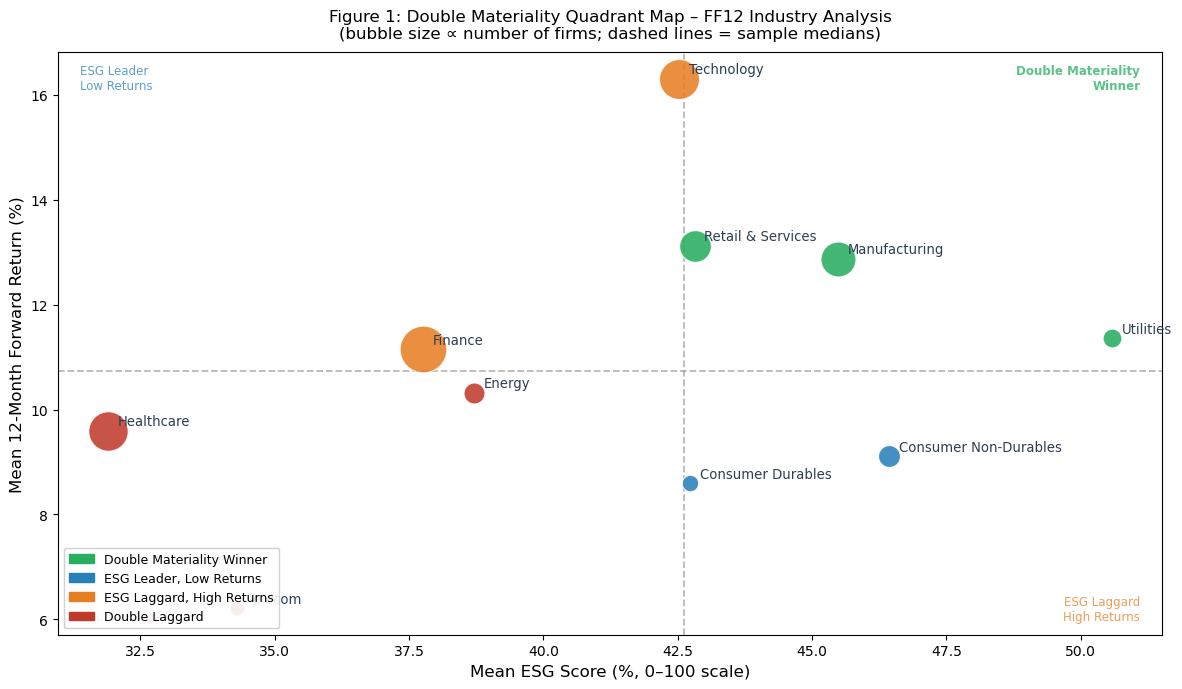

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in grp.iterrows():
    ax.scatter(
        row["esg_mean"], row["ret_mean"],
        s   = row["n_firms"] * 1.8,
        color = row["color"],
        alpha = 0.87, edgecolors="white", linewidth=0.8, zorder=3
    )
    ax.annotate(
        row["Industry"],
        (row["esg_mean"], row["ret_mean"]),
        textcoords="offset points", xytext=(7, 4),
        fontsize=9.5, color="#2c3e50"
    )

ax.axvline(ESG_CUT, color="grey", linestyle="--", linewidth=1.3, alpha=0.55, zorder=2)
ax.axhline(RET_CUT, color="grey", linestyle="--", linewidth=1.3, alpha=0.55, zorder=2)

# Quadrant corner labels
xlim = ax.get_xlim(); ylim = ax.get_ylim()
offset_x = (xlim[1]-xlim[0]) * 0.02
offset_y = (ylim[1]-ylim[0]) * 0.02
ax.text(xlim[0]+offset_x, ylim[1]-offset_y, "ESG Leader\nLow Returns",
        ha="left", va="top", fontsize=8.5, color="#2980b9", alpha=0.75)
ax.text(xlim[1]-offset_x, ylim[1]-offset_y, "Double Materiality\nWinner",
        ha="right", va="top", fontsize=8.5, color="#27ae60", alpha=0.75, fontweight="bold")
ax.text(xlim[0]+offset_x, ylim[0]+offset_y, "Double Laggard",
        ha="left", va="bottom", fontsize=8.5, color="#c0392b", alpha=0.75)
ax.text(xlim[1]-offset_x, ylim[0]+offset_y, "ESG Laggard\nHigh Returns",
        ha="right", va="bottom", fontsize=8.5, color="#e67e22", alpha=0.75)

patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=patches, fontsize=9, loc="lower left", framealpha=0.9)

ax.set_xlabel("Mean ESG Score (%, 0–100 scale)", fontsize=12)
ax.set_ylabel("Mean 12-Month Forward Return (%)", fontsize=12)
ax.set_title(
    "Figure 1: Double Materiality Quadrant Map – FF12 Industry Analysis\n"
    "(bubble size ∝ number of firms; dashed lines = sample medians)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.show()

## 9. Figure 2 – ESG vs. ROA

Using accounting performance (ROA) instead of market returns to test whether the
ESG–performance relation is robust across both dimensions of financial materiality.

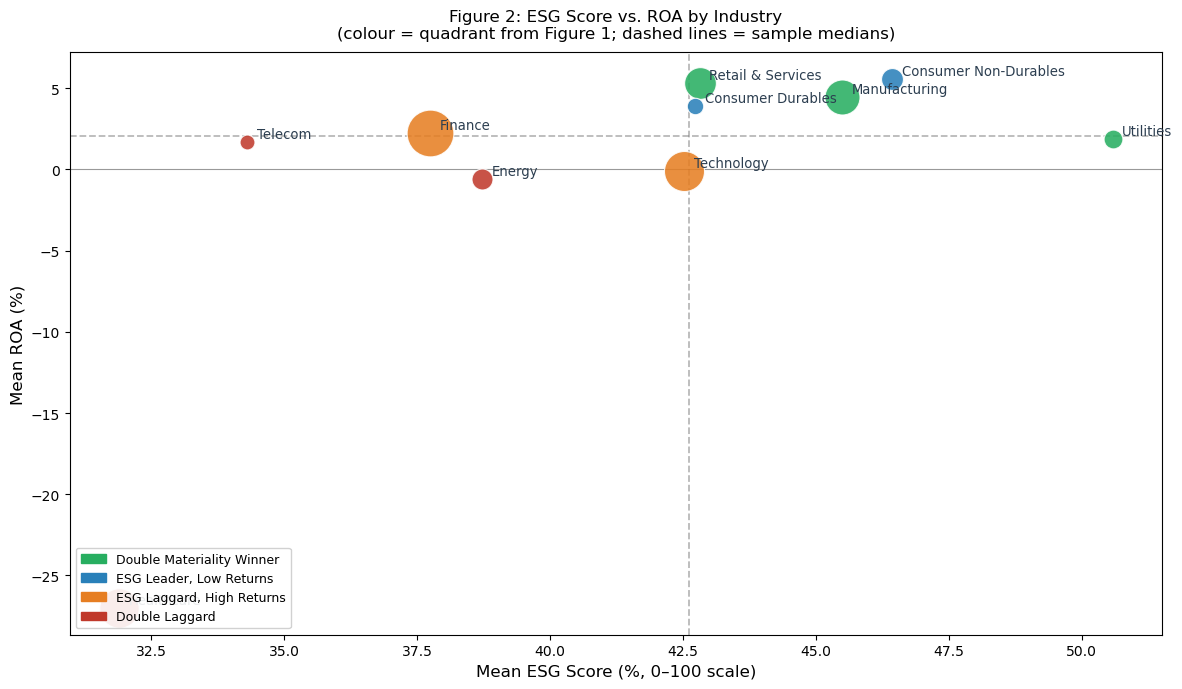

In [ ]:
ROA_CUT = grp["roa_mean"].median()

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in grp.iterrows():
    ax.scatter(
        row["esg_mean"], row["roa_mean"],
        s     = row["n_firms"] * 1.8,
        color = row["color"],
        alpha = 0.87, edgecolors="white", linewidth=0.8, zorder=3
    )
    ax.annotate(
        row["Industry"],
        (row["esg_mean"], row["roa_mean"]),
        textcoords="offset points", xytext=(7, 3),
        fontsize=9.5, color="#2c3e50"
    )

ax.axvline(ESG_CUT,  color="grey", linestyle="--", linewidth=1.3, alpha=0.55)
ax.axhline(ROA_CUT,  color="grey", linestyle="--", linewidth=1.3, alpha=0.55)
ax.axhline(0,        color="black", linewidth=0.8, alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=patches, fontsize=9, loc="lower left", framealpha=0.9)

ax.set_xlabel("Mean ESG Score (%, 0–100 scale)", fontsize=12)
ax.set_ylabel("Mean ROA (%)", fontsize=12)
ax.set_title(
    "Figure 2: ESG Score vs. ROA by Industry\n"
    "(colour = quadrant from Figure 1; dashed lines = sample medians)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.show()

## 10. Figure 3 – Performance heatmap

Each cell shows the **raw value**; colour reflects the **normalised rank** within
each metric column (green = highest, red = lowest).  
This lets us compare across dimensions at a glance.

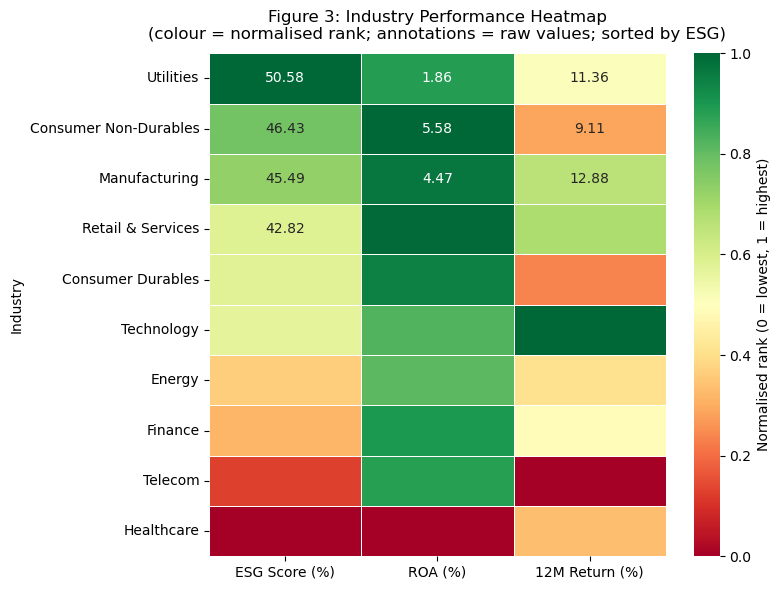

In [ ]:
heat_raw = (
    grp.set_index("Industry")[["esg_mean", "roa_mean", "ret_mean"]]
    .rename(columns={
        "esg_mean": "ESG Score (%)",
        "roa_mean": "ROA (%)",
        "ret_mean": "12M Return (%)"
    })
    .sort_values("ESG Score (%)", ascending=False)
)

heat_norm = (heat_raw - heat_raw.min()) / (heat_raw.max() - heat_raw.min())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heat_norm,
    annot=heat_raw.round(2),
    fmt="g",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Normalised rank (0 = lowest, 1 = highest)"},
    ax=ax
)
ax.set_title(
    "Figure 3: Industry Performance Heatmap\n"
    "(colour = normalised rank; annotations = raw values; sorted by ESG)",
    fontsize=12, pad=10
)
ax.set_xlabel("")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## 11. Figure 4 – ESG score trends by quadrant (2013–2023)

Are double materiality winners improving their ESG faster than other groups?

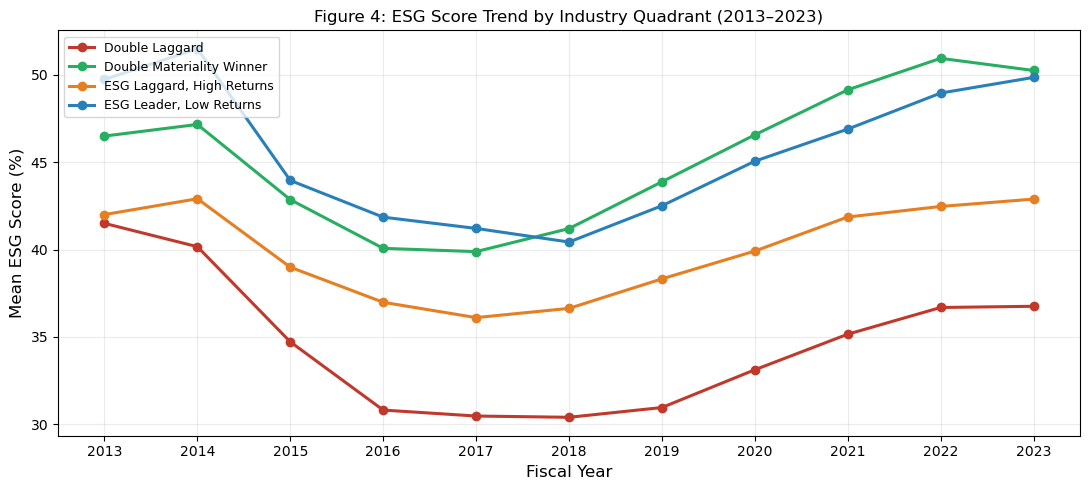

In [ ]:
# Merge quadrant labels back to firm-year panel
df_iv2 = df_iv.merge(
    grp[["Industry", "Quadrant"]].rename(columns={"Industry": "ff12"}),
    on="ff12", how="left"
)

esg_trend = (
    df_iv2.groupby(["fyear", "Quadrant"])["esg_pct"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for quad, sub in esg_trend.groupby("Quadrant"):
    ax.plot(
        sub["fyear"], sub["esg_pct"],
        marker="o", linewidth=2.2,
        color=COLORS.get(quad, "grey"),
        label=quad
    )

ax.set_xlabel("Fiscal Year", fontsize=12)
ax.set_ylabel("Mean ESG Score (%)", fontsize=12)
ax.set_title("Figure 4: ESG Score Trend by Industry Quadrant (2013–2023)", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xticks(df_iv2["fyear"].unique())

plt.tight_layout()
plt.show()

## 12. Tension industries

Here we explicitly identify which industries present an alignment or a conflict
between ESG impact and financial returns, and what this implies for ESG-conscious
investors.

In [14]:
for quadrant in [
    "Double Materiality Winner",
    "ESG Leader, Low Returns",
    "ESG Laggard, High Returns",
    "Double Laggard"
]:
    subset = grp[grp["Quadrant"] == quadrant]
    print(f"\n── {quadrant} ──")
    if len(subset) == 0:
        print("  (none in this sample)")
    else:
        print(subset[["Industry","esg_mean","roa_mean","ret_mean","n_firms"]]
              .rename(columns={
                  "esg_mean":"ESG (%)","roa_mean":"ROA (%)","ret_mean":"Return (%)","n_firms":"N Firms"
              })
              .to_string(index=False))


── Double Materiality Winner ──
         Industry  ESG (%)  ROA (%)  Return (%)  N Firms
        Utilities  50.5849   1.8576     11.3631      102
    Manufacturing  45.4856   4.4734     12.8755      353
Retail & Services  42.8158   5.3353     13.1264      290

── ESG Leader, Low Returns ──
             Industry  ESG (%)  ROA (%)  Return (%)  N Firms
Consumer Non-Durables  46.4322   5.5792      9.1074      138
    Consumer Durables  42.7286   3.8925      8.5949       78

── ESG Laggard, High Returns ──
  Industry  ESG (%)  ROA (%)  Return (%)  N Firms
Technology  42.5207  -0.0837     16.3073      462
   Finance  37.7513   2.2308     11.1479      630

── Double Laggard ──
  Industry  ESG (%)  ROA (%)  Return (%)  N Firms
    Energy  38.7175  -0.6194     10.3174      127
   Telecom  34.3026   1.6748      6.2122       64
Healthcare  31.9005 -27.0189      9.5995      449


## 13. Industry recommendation

We select the **double materiality winner** with the highest combined z-score
across ESG performance and stock return. This optimises both the investor's
financial goal and ESG impact simultaneously.

In [15]:
winners = grp[grp["Quadrant"] == "Double Materiality Winner"].copy()

if len(winners) >= 2:
    winners["z_esg"] = stats.zscore(winners["esg_mean"])
    winners["z_ret"] = stats.zscore(winners["ret_mean"])
    winners["combined_z"] = winners["z_esg"] + winners["z_ret"]
    rec = winners.loc[winners["combined_z"].idxmax(), "Industry"]
elif len(winners) == 1:
    rec = winners.iloc[0]["Industry"]
else:
    # Fall-back: best ESG among above-median return industries
    above_med_ret = grp[grp["ret_mean"] >= RET_CUT]
    rec = above_med_ret.loc[above_med_ret["esg_mean"].idxmax(), "Industry"]

print(f"Recommended industry: {rec}")
print()
print(winners.sort_values("combined_z", ascending=False)[
    ["Industry","esg_mean","ret_mean","roa_mean","combined_z","n_firms"]
].rename(columns={
    "esg_mean":"ESG (%)","ret_mean":"Return (%)","roa_mean":"ROA (%)","n_firms":"N Firms"
}).to_string(index=False))

Recommended industry: Manufacturing

         Industry  ESG (%)  Return (%)  ROA (%)  combined_z  N Firms
    Manufacturing  45.4856     12.8755   4.4734      0.2887      353
        Utilities  50.5849     11.3631   1.8576     -0.0710      102
Retail & Services  42.8158     13.1264   5.3353     -0.2176      290


## 14. Table 2 – Firm-level descriptive statistics for the recommended industry

In [20]:
rec_df = df_iv[df_iv["ff12"] == rec].copy()

stats_map = {
    "esg_pct"   : "ESG Score (%)",
    "roa_pct"   : "ROA (%)",
    "ret_pct"   : "12M Return (%)",
    "size_w"    : "Firm Size (log AT)",
    "lev_w"     : "Leverage",
}

desc = rec_df[list(stats_map.keys())].describe().T
desc.index = list(stats_map.values())
desc = desc[["count","mean","std","min","25%","50%","75%","max"]].round(3)

print(f"Table 2: Firm-Level Descriptive Statistics – {rec}")
print(desc.to_string())

Table 2: Firm-Level Descriptive Statistics – Manufacturing
                       count    mean     std      min      25%     50%     75%      max
ESG Score (%)      2563.0000 45.4860 19.9070   8.0740  28.8960 44.8230 61.7210  84.9930
ROA (%)            2563.0000  4.4730  9.7620 -82.2310   1.9100  5.3060  8.8780  26.9910
12M Return (%)     2563.0000 12.8760 43.2210 -75.9470 -13.2780  8.3520 32.7260 217.5680
Firm Size (log AT) 2563.0000  7.8410  1.4740   3.7320   6.9300  7.8300  8.7960  12.2000
Leverage           2563.0000  0.3010  0.1770   0.0000   0.1890  0.2940  0.4050   0.9630


## 15. Figure 5 – Recommended industry performance trends

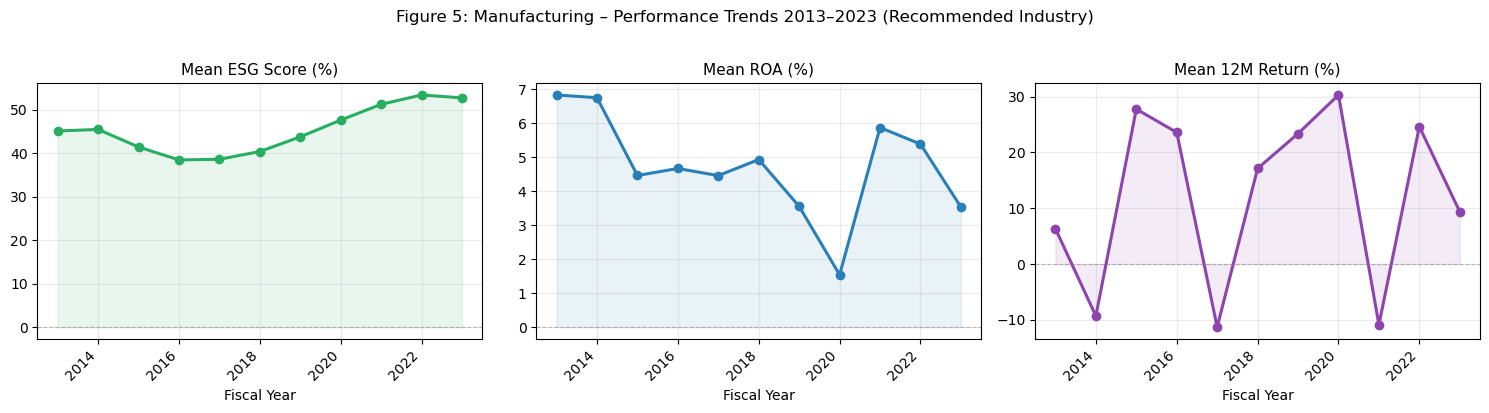

In [21]:
rec_trend = (
    rec_df.groupby("fyear")
    .agg(
        n_firms  = ("gvkey",  "nunique"),
        esg_mean = ("esg_pct", "mean"),
        roa_mean = ("roa_pct", "mean"),
        ret_mean = ("ret_pct", "mean"),
    )
    .reset_index()
    .sort_values("fyear")
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

specs = [
    ("esg_mean", "Mean ESG Score (%)",  "#27ae60"),
    ("roa_mean", "Mean ROA (%)",         "#2980b9"),
    ("ret_mean", "Mean 12M Return (%)", "#8e44ad"),
]

for ax, (col, label, color) in zip(axes, specs):
    ax.plot(rec_trend["fyear"], rec_trend[col],
            marker="o", linewidth=2.2, color=color)
    ax.fill_between(rec_trend["fyear"], rec_trend[col],
                    alpha=0.1, color=color)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Fiscal Year")
    ax.grid(True, alpha=0.25)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle(
    f"Figure 5: {rec} – Performance Trends 2013–2023 (Recommended Industry)",
    fontsize=12, y=1.02
)

plt.tight_layout()
plt.show()

## 17. Table 3 – Regression: ESG → forward returns

We run `future_return ~ lag_esg + lag_roa + lag_size + lag_lev + year FE + industry FE`
for the full sample and for the recommended industry alone, using HC1 robust
standard errors (consistent with Parts II–III).

In [22]:
# Build lagged regressors on the Part IV sub-panel
df_iv2 = df_iv2.sort_values(["gvkey", "fyear"])
for col, new in [("esg_pct","lag_esg"), ("roa_pct","lag_roa_iv"),
                 ("size_w","lag_size_iv"), ("lev_w","lag_lev_iv")]:
    df_iv2[new] = df_iv2.groupby("gvkey")[col].shift(1)

for col in ["lag_esg","lag_roa_iv","lag_size_iv","lag_lev_iv"]:
    df_iv2[col] = winsorize_series(df_iv2[col])


def reg_summary(model, name):
    coef = model.params.get("lag_esg", float("nan"))
    se   = model.bse.get("lag_esg", float("nan"))
    pval = model.pvalues.get("lag_esg", float("nan"))
    stars = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.10 else ""))
    return {
        "Model"         : name,
        "ESG coef"      : round(coef, 4),
        "Std Err"       : round(se,   4),
        "p-value"       : round(pval, 4),
        "Sig."          : stars,
        "N"             : int(model.nobs),
        "Adj R²"        : round(model.rsquared_adj, 4),
    }


# Model 1: full sample, no industry FE
reg_base = df_iv2[["ret_pct","lag_esg","lag_roa_iv","lag_size_iv",
                    "lag_lev_iv","fyear","ff12"]].dropna()
m1 = smf.ols(
    "ret_pct ~ lag_esg + lag_roa_iv + lag_size_iv + lag_lev_iv + C(fyear)",
    data=reg_base
).fit(cov_type="HC1")

# Model 2: full sample + industry FE
m2 = smf.ols(
    "ret_pct ~ lag_esg + lag_roa_iv + lag_size_iv + lag_lev_iv + C(fyear) + C(ff12)",
    data=reg_base
).fit(cov_type="HC1")

# Model 3: recommended industry only
reg_rec = df_iv2.loc[df_iv2["ff12"] == rec,
    ["ret_pct","lag_esg","lag_roa_iv","lag_size_iv","lag_lev_iv","fyear"]].dropna()
m3 = smf.ols(
    "ret_pct ~ lag_esg + lag_roa_iv + lag_size_iv + lag_lev_iv + C(fyear)",
    data=reg_rec
).fit(cov_type="HC1")


table3 = pd.DataFrame([
    reg_summary(m1, "Full sample – year FE only"),
    reg_summary(m2, "Full sample – year + industry FE"),
    reg_summary(m3, f"{rec} only – year FE"),
])

print("Table 3: ESG → 12-Month Forward Return (HC1 robust SE)")
print(table3.to_string(index=False))
table3.to_csv("part4_table3_esg_return_regression.csv", index=False)

Table 3: ESG → 12-Month Forward Return (HC1 robust SE)
                           Model  ESG coef  Std Err  p-value Sig.     N  Adj R²
      Full sample – year FE only   -0.0105   0.0233   0.6532      14260  0.0784
Full sample – year + industry FE   -0.0304   0.0261   0.2433      14260  0.0817
    Manufacturing only – year FE   -0.0687   0.0632   0.2767       2210  0.1279


## 18. Summary of key findings

In [24]:
print("=" * 60)
print("PART IV – SUMMARY")
print("=" * 60)

print("\n1. DOUBLE MATERIALITY WINNERS")
print(grp.loc[grp["Quadrant"]=="Double Materiality Winner",
    ["Industry","esg_mean","ret_mean"]].to_string(index=False))

print("\n2. TENSIONS – ESG Leader but Low Returns")
print(grp.loc[grp["Quadrant"]=="ESG Leader, Low Returns",
    ["Industry","esg_mean","ret_mean"]].to_string(index=False))

print("\n3. TENSIONS – High Returns but Low ESG")
print(grp.loc[grp["Quadrant"]=="ESG Laggard, High Returns",
    ["Industry","esg_mean","ret_mean"]].to_string(index=False))

print("\n4. DOUBLE LAGGARDS")
print(grp.loc[grp["Quadrant"]=="Double Laggard",
    ["Industry","esg_mean","ret_mean"]].to_string(index=False))

print(f"\n5. RECOMMENDED INDUSTRY: {rec}")
row = grp[grp["Industry"]==rec].iloc[0]
print(f"   ESG mean: {row['esg_mean']:.2f}%  |  Return mean: {row['ret_mean']:.2f}%  |  ROA mean: {row['roa_mean']:.2f}%")

PART IV – SUMMARY

1. DOUBLE MATERIALITY WINNERS
         Industry  esg_mean  ret_mean
        Utilities   50.5849   11.3631
    Manufacturing   45.4856   12.8755
Retail & Services   42.8158   13.1264

2. TENSIONS – ESG Leader but Low Returns
             Industry  esg_mean  ret_mean
Consumer Non-Durables   46.4322    9.1074
    Consumer Durables   42.7286    8.5949

3. TENSIONS – High Returns but Low ESG
  Industry  esg_mean  ret_mean
Technology   42.5207   16.3073
   Finance   37.7513   11.1479

4. DOUBLE LAGGARDS
  Industry  esg_mean  ret_mean
    Energy   38.7175   10.3174
   Telecom   34.3026    6.2122
Healthcare   31.9005    9.5995

5. RECOMMENDED INDUSTRY: Manufacturing
   ESG mean: 45.49%  |  Return mean: 12.88%  |  ROA mean: 4.47%
